In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np

In [2]:
PT = pd.read_csv('PTs.txt', sep=" ", index_col=0)
VL = pd.read_csv('VLs.txt', sep=" ", index_col=0)

COLs = ["teal", "orangered", "darkorange", "navy", "deeppink", "gray", "sienna", "slateblue", "mediumseagreen", "steelblue", "olivedrab"]

In [3]:
AlbeDalla = pd.read_csv('AlbeDalla.txt', sep=" ", index_col=0, header=None)
NarutinoAlberio = pd.read_csv('NarutinoAlberio.txt', sep=" ", index_col=0, header=None)
PittorWoody = pd.read_csv('PittorWoody.txt', sep=" ", index_col=0, header=None)

HarrysOnFord = pd.read_csv('HarrysOnFord.txt', sep=" ", index_col=0, header=None)
EinAudi = pd.read_csv('EinAudi.txt', sep=" ", index_col=0, header=None)
DiMaleInPeugeot = pd.read_csv('DiMaleInPeugeot.txt', sep=" ", index_col=0, header=None)

Penalties = [len(PT.iloc[0])*[0],                                       # AlbeDalla
             len(PT.iloc[0])*[0],                                       # NarutinoAlberio
             3*[0]+[-10,0,-10]+(len(PT.iloc[0])-6)*[0],                 # PittorWoody
             len(PT.iloc[0])*[0],                                       # HarrysOnFord
             len(PT.iloc[0])*[0],                                       # EinAudi
             [0,-10,-30]+8*[0]+[-47,-50,-41]+(len(PT.iloc[0])-14)*[0]]  # DiMaleInPeugeot

myDF = [AlbeDalla, NarutinoAlberio, PittorWoody, HarrysOnFord, EinAudi, DiMaleInPeugeot]
legDF = ["AlbeDalla", "NarutinoAlberio", "PittorWoody", "HarrysOnFord", "EinAudi", "DiMaleInPeugeot"]
colDF = ["cyan", "cornflowerblue", "darkturquoise", "chocolate", "burlywood", "gold"]

In [4]:
LEG = PT.index.tolist()
fig, ax = plt.subplots(4,3, figsize=(25,16), dpi=400)

for jj in range(int(len(PT)/3)):
    ax[jj//3,jj%3].plot(PT.iloc[jj*3], label=LEG[jj*3], linewidth=3.5, color=COLs[jj])
    ax[jj//3,jj%3].plot(PT.iloc[jj*3+1], "--", label=LEG[jj*3+1], linewidth=3.5, color=COLs[jj])
    ax[jj//3,jj%3].plot(PT.iloc[jj*3+2], ":", label=LEG[jj*3+2], linewidth=3.5, color=COLs[jj])
    
    ax[jj//3,jj%3].grid(color="darkgray", linestyle=':', linewidth=0.5)
    ax[jj//3,jj%3].legend(fontsize=12)
    ax[jj//3,jj%3].tick_params("x", labelrotation=30)
    #ax[jj//3,jj%3].set_ylim(-40,120)
    
ax[3,2].axis("off")
plt.table(cellText=[[LEG[ii]]+PT.iloc[ii].tolist() for ii in range(len(PT))],
          cellColours=[(1+len(PT.columns))*[0.55*(np.array(mcolors.to_rgb("white"))) + 0.45*(np.array(mcolors.to_rgb(COLs[ii//3])))] for ii in range(len(PT))],
          colLabels=["ID."]+PT.columns.tolist(),
          colWidths=[0.22]+len(PT.columns)*[0.26],
          bbox=[1.1, 0, 1.4, 4.6])

fig.suptitle("POINTS", fontsize=24, weight="bold", y=0.91)

Text(0.5, 0.91, 'POINTS')

In [5]:
LEG = VL.index.tolist()
fig, ax = plt.subplots(4,3, figsize=(25,16), dpi=400)

for jj in range(int(len(VL)/3)):
    ax[jj//3,jj%3].plot(VL.iloc[jj*3], label=LEG[jj*3], linewidth=3.5, color=COLs[jj])
    ax[jj//3,jj%3].plot(VL.iloc[jj*3+1], "--", label=LEG[jj*3+1], linewidth=3.5, color=COLs[jj])
    ax[jj//3,jj%3].plot(VL.iloc[jj*3+2], ":", label=LEG[jj*3+2], linewidth=3.5, color=COLs[jj])
    
    ax[jj//3,jj%3].grid(color="darkgray", linestyle=':', linewidth=0.5)
    ax[jj//3,jj%3].legend(fontsize=12)
    ax[jj//3,jj%3].tick_params("x", labelrotation=30)
    #ax[jj//3,jj%3].set_ylim(-40,120)
    
ax[3,2].axis("off")
plt.table(cellText=[[LEG[ii]]+VL.iloc[ii].tolist() for ii in range(len(VL))],
        cellColours=[(1+len(VL.columns))*[0.55*(np.array(mcolors.to_rgb("white"))) + 0.45*(np.array(mcolors.to_rgb(COLs[ii//3])))] for ii in range(len(VL))],
        colLabels=["ID."]+VL.columns.tolist(),
        colWidths=[0.22]+len(VL.columns)*[0.26],
        bbox=[1.1, 0, 1.4, 4.6])

fig.suptitle("VALUE", fontsize=24, weight="bold", y=0.91)

Text(0.5, 0.91, 'VALUE')

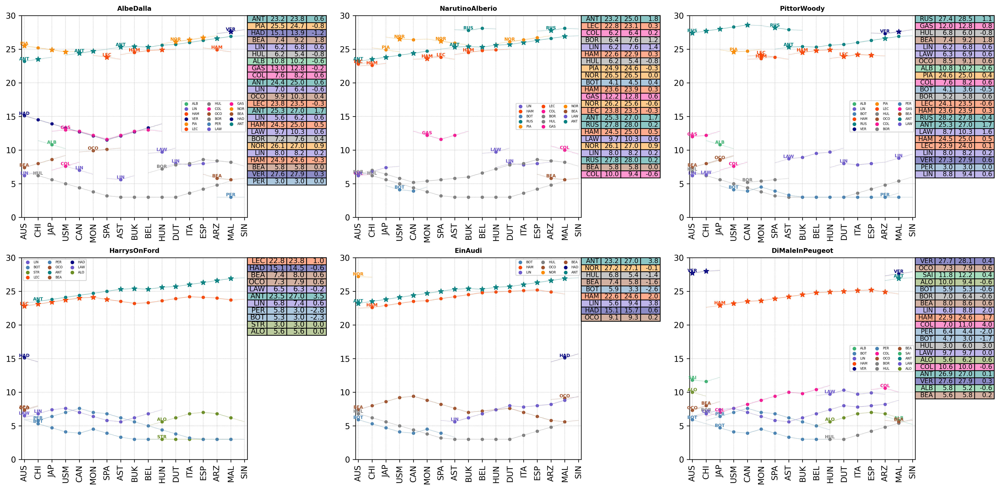

In [6]:
fig,ax = plt.subplots(2,3, figsize=(20,10), dpi=300)
plt.subplots_adjust(left=None, bottom=None, right=None, top=None, wspace=0.48, hspace=None)

for jj in range(len(myDF)):
    for we in PT.columns:
        for driver in myDF[jj].iloc[VL.columns.tolist().index(we)][:-2]:
            ax[jj//3,jj%3].scatter(VL.columns.tolist().index(we), VL.loc[driver[:3],we],
                                   marker = "*" if driver[-1]=="*" else ".", s=40,
                                   color=COLs[int(PT.index.tolist().index(driver[:3])/3)])
            ax[jj//3,jj%3].plot(VL.columns[max(VL.columns.tolist().index(we)-1, 0) : min(VL.columns.tolist().index(we)+2,len(VL.columns))],
                                VL.loc[driver[:3], VL.columns.tolist()[max(VL.columns.tolist().index(we)-1, 0):min(VL.columns.tolist().index(we)+2, len(VL.columns))]],
                                ":", linewidth=0.4, color=COLs[int(PT.index.tolist().index(driver[:3])/3)])
            if we==PT.columns.tolist()[0] or driver[:3] not in [aa[:3] for aa in myDF[jj].iloc[VL.columns.tolist().index(we)-1][:-2]]:
                ax[jj//3,jj%3].text(VL.columns.tolist().index(we), VL.loc[driver[:3],we], driver[:3],
                                    ha="center", va="bottom", weight="bold", fontsize=5.5,
                                    color=COLs[int(PT.index.tolist().index(driver[:3])/3)])
    driverValue = []
    for ii in range(len(VL.columns)-1):
        for driver in [aa[:3] for aa in myDF[jj].iloc[ii][:-2]]:
            if ii==0 or driver not in [aa[:3] for aa in myDF[jj].iloc[ii-1][:-2].tolist()]:
                driverValue.append([driver,VL.loc[driver,PT.columns[ii]]])
            if (ii==len(VL.columns)-2) or ((ii!=len(VL.columns)-2) and (driver not in [aa[:3] for aa in myDF[jj].iloc[ii+1][:-2].tolist()])):
                driverValue[len(driverValue)-1-[aa[0] for aa in driverValue][::-1].index(driver)].append(VL.loc[driver,VL.columns[ii+1]])
    drivers = list(set(sum([[aa[:3] for aa in myDF[jj].iloc[ii][:-2]] for ii in range(len(myDF[jj]))],[])))
    for driver in drivers:
        ax[jj//3,jj%3].scatter(-1, 0, marker=".", s=50, color=COLs[int(PT.index.tolist().index(driver[:3])/3)], label=driver)
    ax[jj//3,jj%3].grid(color="darkgray", linestyle=':', linewidth=0.5)
    ax[jj//3,jj%3].legend(fontsize=4, ncol=3)
    ax[jj//3,jj%3].set_xlim(-0.2,len(VL.columns)-0.8)
    ax[jj//3,jj%3].tick_params(axis='x', labelrotation=90)
    #ax[jj//3,jj%3].set_ylim(min([min(VL.loc[driver[:3],:]) for driver in drivers])//5*5, (1+max([max(VL.loc[driver[:3],:]) for driver in drivers])//5)*5)
    ax[jj//3,jj%3].set_ylim(0,30)
    ax[jj//3,jj%3].set_title(legDF[jj], fontsize=8, weight="bold")
    ax[jj//3,jj%3].table(cellText=[aa+["%.1f"%(aa[2]-aa[1])] for aa in driverValue],
                         cellColours=[4*[0.55*(np.array(mcolors.to_rgb("white"))) + 0.45*(np.array(mcolors.to_rgb(COLs[int(PT.index.tolist().index(aa[0])/3)])))] for aa in driverValue],
                         #colWidths=[0.45, 0.1, 0.45],
                         bbox=[1, 1-0.035*(len(driverValue)), 0.35, 0.035*(len(driverValue))])

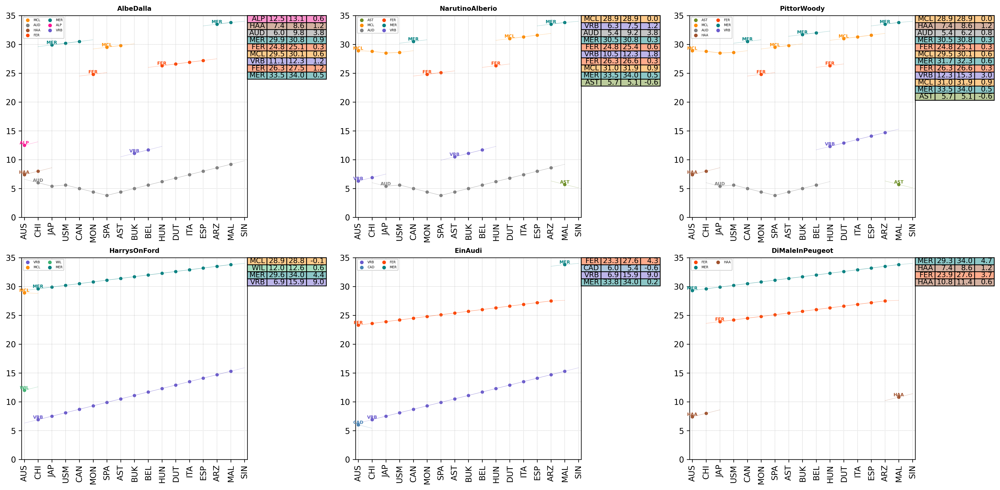

In [7]:
fig,ax = plt.subplots(2,3, figsize=(20,10), dpi=300)
plt.subplots_adjust(left=None, bottom=None, right=None, top=None, wspace=0.48, hspace=None)

for jj in range(len(myDF)):
    for we in PT.columns:
        for team in myDF[jj].iloc[VL.columns.tolist().index(we)][-2:]:
            ax[jj//3,jj%3].scatter(VL.columns.tolist().index(we), VL.loc[team,we],
                                   marker = ".", s=40,
                                   color=COLs[int(PT.index.tolist().index(team)/3)])
            ax[jj//3,jj%3].plot(VL.columns[max(VL.columns.tolist().index(we)-1, 0) : min(VL.columns.tolist().index(we)+2,len(VL.columns))],
                                VL.loc[team, VL.columns.tolist()[max(VL.columns.tolist().index(we)-1, 0):min(VL.columns.tolist().index(we)+2, len(VL.columns))]],
                                ":", linewidth=0.4, color=COLs[int(PT.index.tolist().index(team)/3)])
            if we==PT.columns.tolist()[0] or team not in myDF[jj].iloc[VL.columns.tolist().index(we)-1][-2:].tolist():
                ax[jj//3,jj%3].text(VL.columns.tolist().index(we), VL.loc[team,we], team,
                                    ha="center", va="bottom", weight="bold", fontsize=5.5,
                                    color=COLs[int(PT.index.tolist().index(team)/3)])
    teamValue = []
    for ii in range(len(VL.columns)-1):
        for team in myDF[jj].iloc[ii][-2:]:
            if ii==0 or team not in myDF[jj].iloc[ii-1][-2:].tolist():
                teamValue.append([team,VL.loc[team,PT.columns[ii]]])
            if (ii==len(VL.columns)-2) or ((ii!=len(VL.columns)-2) and (team not in myDF[jj].iloc[ii+1][-2:].tolist())):
                teamValue[len(teamValue)-1-[aa[0] for aa in teamValue][::-1].index(team)].append(VL.loc[team,VL.columns[ii+1]])
    teams = list(set(sum([myDF[jj].iloc[ii][-2:].tolist() for ii in range(len(myDF[jj]))],[])))
    for team in teams:
        ax[jj//3,jj%3].scatter(-1, 0, marker=".", s=50, color=COLs[int(PT.index.tolist().index(team)/3)], label=team)
    ax[jj//3,jj%3].grid(color="darkgray", linestyle=':', linewidth=0.5)
    ax[jj//3,jj%3].legend(fontsize=4, ncol=2)
    ax[jj//3,jj%3].set_xlim(-0.2,len(VL.columns)-0.8)
    ax[jj//3,jj%3].tick_params(axis='x', labelrotation=90)
    #ax[jj//3,jj%3].set_ylim(min([min(VL.loc[driver[:3],:]) for driver in drivers])//5*5, (1+max([max(VL.loc[driver[:3],:]) for driver in drivers])//5)*5)
    ax[jj//3,jj%3].set_ylim(0,35)
    ax[jj//3,jj%3].set_title(legDF[jj], fontsize=8, weight="bold")
    ax[jj//3,jj%3].table(cellText=[aa+["%.1f"%(aa[2]-aa[1])] for aa in teamValue],
                         cellColours=[4*[0.55*(np.array(mcolors.to_rgb("white"))) + 0.45*(np.array(mcolors.to_rgb(COLs[int(PT.index.tolist().index(aa[0])/3)])))] for aa in teamValue],
                         #colWidths=[0.45, 0.1, 0.45],
                         bbox=[1, 1-0.035*(len(teamValue)), 0.35, 0.035*(len(teamValue))])

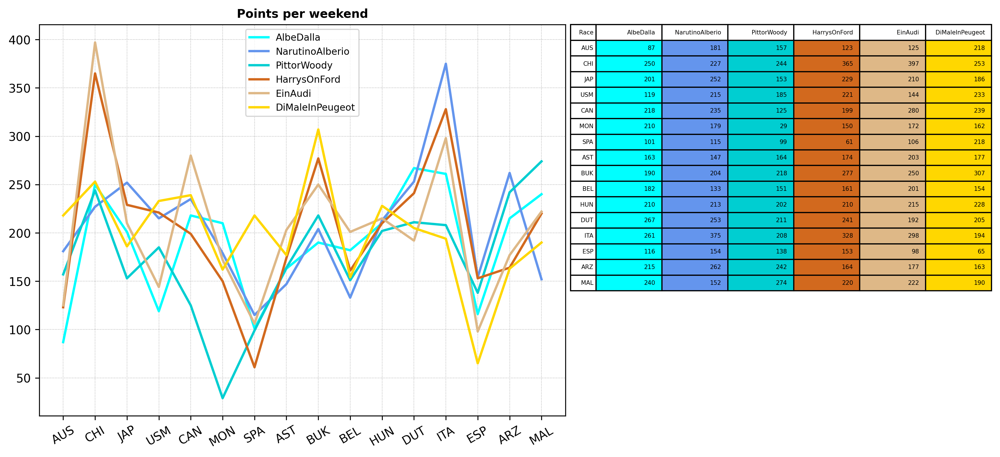

In [8]:
myTab = [["Race"]+legDF]
fig,ax = plt.subplots(1,1, figsize=(8,6), dpi=300)

for jj in range(len(myDF)):
    score = [Penalties[jj][list(PT.columns).index(we)] + sum([2*PT.loc[selection[:3],we] if selection[-1]=="*" else PT.loc[selection[:3],we] for selection in myDF[jj].iloc[PT.columns.tolist().index(we)] ]) for we in PT.columns]
    ax.plot(PT.columns, score, label=legDF[jj], linewidth=2, color=colDF[jj])
ax.legend(fontsize=8)
ax.grid(color="darkgray", linestyle=':', linewidth=0.5)
ax.set_title("Points per weekend", fontsize=10, weight="bold")
ax.tick_params("x", labelrotation=30)

for we in PT.columns:
    myTab.append([we] + [int(Penalties[jj][list(PT.columns).index(we)] + sum([2*PT.loc[selection[:3],we] if selection[-1]=="*" else PT.loc[selection[:3],we] for selection in myDF[jj].loc[we]])) for jj in range(len(myDF))])

plt.table(cellText=myTab,
          cellColours=[7*["white"]] + (len(myTab)-1)*[(["white"]+colDF)],
          colWidths=[0.06]+6*[(1-0.06)/6],
          bbox=[1.01, 1-0.04*(1+len(PT.columns)), 0.8, 0.04*(1+len(PT.columns))])

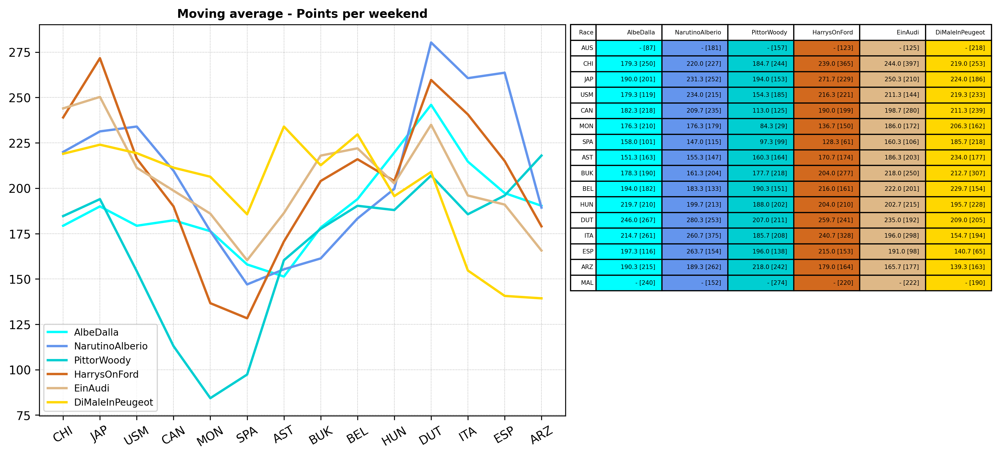

In [9]:
myTab = [["Race"]+legDF]
fig,ax = plt.subplots(1,1, figsize=(8,6), dpi=300)
myMovingAverageScore = []

for jj in range(len(myDF)):
    score = [Penalties[jj][list(PT.columns).index(we)] + sum([2*PT.loc[selection[:3],we] if selection[-1]=="*" else PT.loc[selection[:3],we] for selection in myDF[jj].iloc[PT.columns.tolist().index(we)] ]) for we in PT.columns]
    myMovingAverageScore.append([sum(score[ii-1:ii+2])/3 for ii in range(1,len(PT.columns)-1)])
    ax.plot(PT.columns[1:-1], myMovingAverageScore[-1], label=legDF[jj], linewidth=2, color=colDF[jj])
    
ax.legend(fontsize=8)
ax.grid(color="darkgray", linestyle=':', linewidth=0.5)
ax.set_title("Moving average - Points per weekend", fontsize=10, weight="bold")
ax.tick_params("x", labelrotation=30)

for we in PT.columns:
    myTab.append([we] + [("-" if we in [PT.columns[0],PT.columns[-1]] else "%.1f"%(myMovingAverageScore[jj][list(PT.columns).index(we)-1])) + " [%d]"%(int(Penalties[jj][list(PT.columns).index(we)] + sum([2*PT.loc[selection[:3],we] if selection[-1]=="*" else PT.loc[selection[:3],we] for selection in myDF[jj].loc[we]]))) for jj in range(len(myDF))])

plt.table(cellText=myTab,
          cellColours=[7*["white"]] + (len(myTab)-1)*[(["white"]+colDF)],
          colWidths=[0.06]+6*[(1-0.06)/6],
          bbox=[1.01, 1-0.04*(1+len(PT.columns)), 0.8, 0.04*(1+len(PT.columns))])

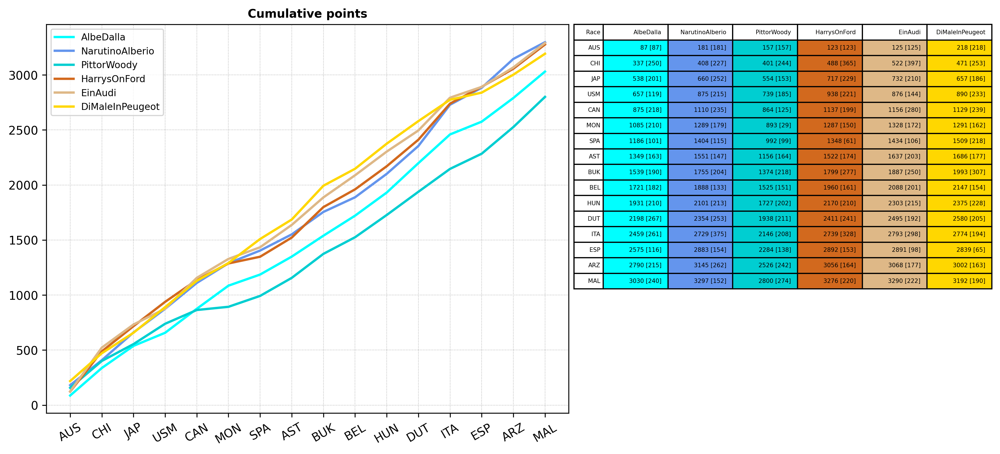

In [10]:
myTab = [["Race"]+legDF]
fig,ax = plt.subplots(1,1, figsize=(8,6), dpi=300)

for jj in range(len(myDF)):
    score = [Penalties[jj][list(PT.columns).index(we)] + sum([2*PT.loc[selection[:3],we] if selection[-1]=="*" else PT.loc[selection[:3],we] for selection in myDF[jj].iloc[PT.columns.tolist().index(we)] ]) for we in PT.columns]
    ax.plot(PT.columns, [sum(score[:ii+1]) for ii in range(len(score))], label=legDF[jj], linewidth=2, color=colDF[jj])
ax.legend(fontsize=8)
ax.grid(color="darkgray", linestyle=':', linewidth=0.5)
ax.set_title("Cumulative points", fontsize=10, weight="bold")
ax.tick_params("x", labelrotation=30)

for ii in range(len(PT.columns)):
    myRow = []
    for jj in range(len(myDF)):
        myRow.append(sum([Penalties[jj][list(PT.columns).index(we)] + sum([2*PT.loc[selection[:3],we] if selection[-1]=="*" else PT.loc[selection[:3],we] for selection in myDF[jj].iloc[PT.columns.tolist().index(we)] ]) for we in PT.columns[:ii+1]]))
    #myTab.append([PT.columns[ii]] + myRow)
    myTab.append([PT.columns[ii]] + ["%d [%d]"%(myRow[jj], Penalties[jj][ii] + sum([2*PT.loc[selection[:3]][PT.columns.tolist()[ii]] if selection[-1]=="*" else PT.loc[selection[:3]][PT.columns.tolist()[ii]] for selection in myDF[jj].iloc[ii]])) for jj in range(len(myRow))])

plt.table(cellText=myTab,
          cellColours=[7*["white"]] + (len(myTab)-1)*[(["white"]+colDF)],
          colWidths=[0.07]+6*[0.155],
          bbox=[1.01, 1-0.04*(1+len(PT.columns)), 0.8, 0.04*(1+len(PT.columns))])

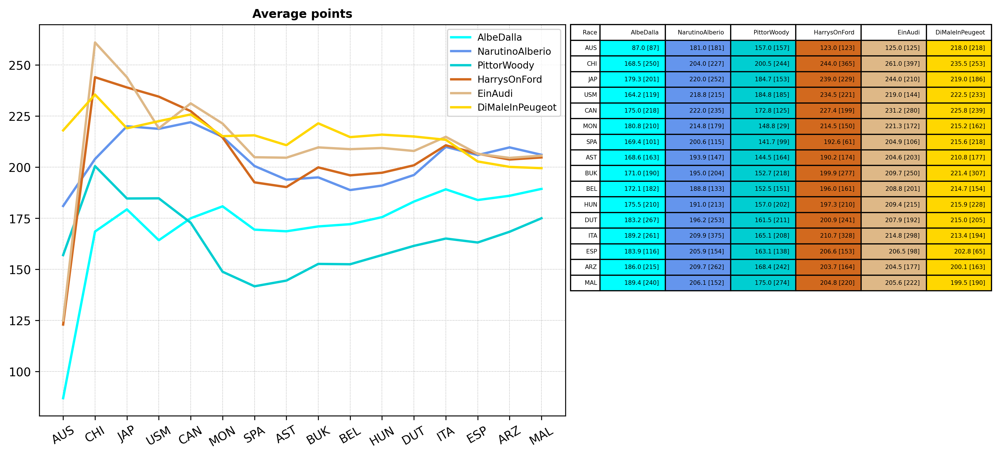

In [11]:
myTab = [["Race"]+legDF]
fig,ax = plt.subplots(1,1, figsize=(8,6), dpi=300)

for jj in range(len(myDF)):
    score = [Penalties[jj][list(PT.columns).index(we)] + sum([2*PT.loc[selection[:3],we] if selection[-1]=="*" else PT.loc[selection[:3],we] for selection in myDF[jj].iloc[PT.columns.tolist().index(we)] ]) for we in PT.columns]
    ax.plot(PT.columns, [sum(score[:ii+1])/(ii+1) for ii in range(len(score))], label=legDF[jj], linewidth=2, color=colDF[jj])
ax.legend(fontsize=8)
ax.grid(color="darkgray", linestyle=':', linewidth=0.5)
ax.set_title("Average points", fontsize=10, weight="bold")
ax.tick_params("x", labelrotation=30)

for ii in range(len(PT.columns)):
    myRow = []
    for jj in range(len(myDF)):
        myRow.append(sum([Penalties[jj][list(PT.columns).index(we)] + sum([2*PT.loc[selection[:3],we] if selection[-1]=="*" else PT.loc[selection[:3],we] for selection in myDF[jj].iloc[PT.columns.tolist().index(we)] ]) for we in PT.columns[:ii+1]]))
    #myTab.append([PT.columns[ii]] + myRow)
    myTab.append([PT.columns[ii]] + ["%.1f [%d]"%(myRow[jj]/(ii+1), Penalties[jj][ii] + sum([2*PT.loc[selection[:3]][PT.columns.tolist()[ii]] if selection[-1]=="*" else PT.loc[selection[:3]][PT.columns.tolist()[ii]] for selection in myDF[jj].iloc[ii]])) for jj in range(len(myRow))])

plt.table(cellText=myTab,
          cellColours=[7*["white"]] + (len(myTab)-1)*[(["white"]+colDF)],
          colWidths=[0.07]+6*[0.155],
          bbox=[1.01, 1-0.04*(1+len(PT.columns)), 0.8, 0.04*(1+len(PT.columns))])

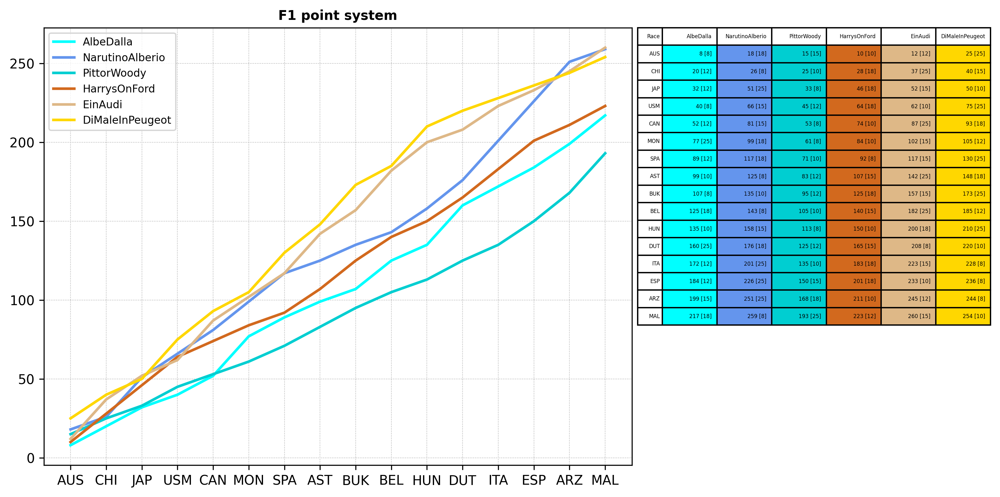

In [12]:
PS = [25, 18, 15, 12, 10, 8][::-1]

myTab = [["Race"]+legDF]
myScore = []
for we in PT.columns:
    teamScore = [Penalties[jj][list(PT.columns).index(we)] + sum([2*PT.loc[selection[:3],we] if selection[-1]=="*" else PT.loc[selection[:3],we] for selection in myDF[jj].iloc[PT.columns.tolist().index(we)] ]) for jj in range(len(myDF))]
    myScore.append([PS[list(sorted(teamScore)).index(teamScore[ii])]+myScore[-1][ii] for ii in range(len(teamScore))] if we!=PT.columns[0] else [PS[list(sorted(teamScore)).index(teamScore[ii])] for ii in range(len(teamScore))])
    myTab.append([we]+["%d [%d]"%(myScore[-1][ii],myScore[-1][ii]-myScore[-2][ii]) for ii in range(len(myDF))] if we!=PT.columns[0] else [we]+["%d [%d]"%(myScore[-1][ii],myScore[-1][ii]) for ii in range(len(myDF))])

fig,ax = plt.subplots(1,1, figsize=(8,6), dpi=300)
for jj in range(len(myDF)):
    teamScore = [myScore[ii][jj] for ii in range(len(PT.columns))]
    ax.plot(PT.columns, [myScore[ii][jj] for ii in range(len(PT.columns))], label=legDF[jj], linewidth=2, color=colDF[jj]) 

ax.legend(fontsize=8)
ax.grid(color="darkgray", linestyle=':', linewidth=0.5)
ax.set_title("F1 point system", fontsize=10, weight="bold")

plt.table(cellText=myTab,
        cellColours=[7*["white"]] + (len(myTab)-1)*[(["white"]+colDF)],
        colWidths=[0.07]+6*[0.155],
        bbox=[1.01, 1-0.04*(1+len(PT.columns)), 0.6, 0.04*(1+len(PT.columns))])

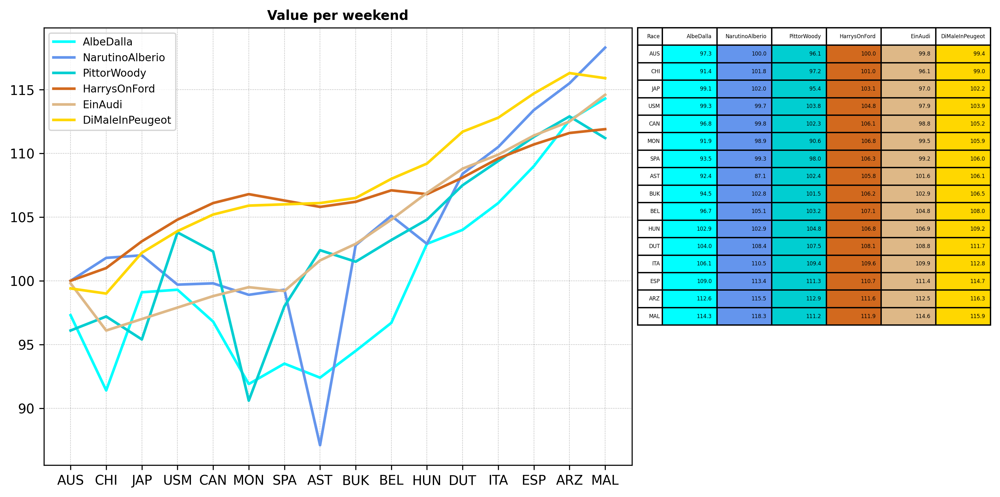

In [13]:
myTab = [["Race"]+legDF]
fig,ax = plt.subplots(1,1, figsize=(8,6), dpi=300)

for jj in range(len(myDF)):
    value = [sum([VL.loc[selection[:3],we] for selection in myDF[jj].iloc[PT.columns.tolist().index(we)] ]) for we in PT.columns]
    ax.plot(PT.columns, value, label=legDF[jj], linewidth=2, color=colDF[jj])
ax.legend(fontsize=8)
ax.grid(color="darkgray", linestyle=':', linewidth=0.5)
ax.set_title("Value per weekend", fontsize=10, weight="bold")

for we in PT.columns:
    myTab.append([we] + ["%.1f"%(sum([VL.loc[selection[:3],we] for selection in myDF[jj].loc[we]])) for jj in range(len(myDF))])

plt.table(cellText=myTab,
          cellColours=[7*["white"]] + (len(myTab)-1)*[(["white"]+colDF)],
          colWidths=[0.07]+6*[0.155],
          bbox=[1.01, 1-0.04*(1+len(PT.columns)), 0.6, 0.04*(1+len(PT.columns))])

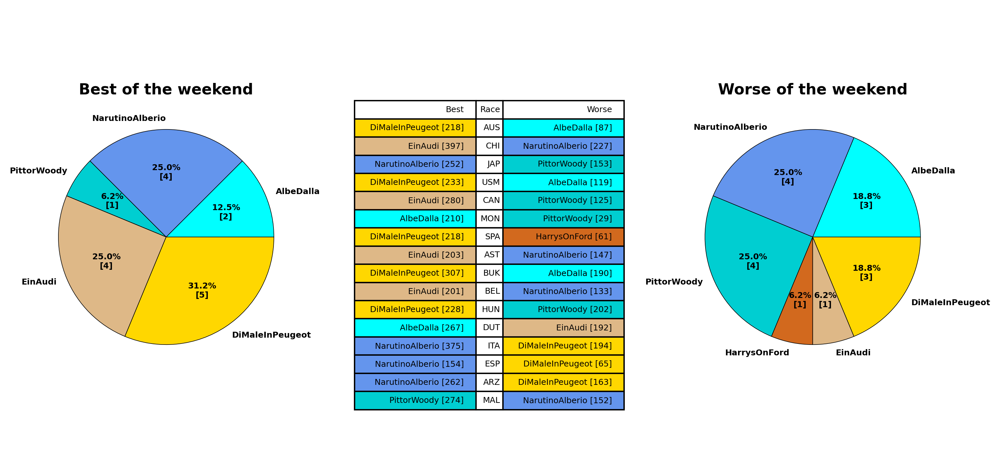

In [14]:
fig,ax = plt.subplots(1,3, figsize=(12,6), dpi=300)

topScorer = [sum([1 if (myScore[ii][jj]-myScore[ii-1][jj]==25 if ii!=0 else myScore[ii][jj]==25) else 0 for ii in range(len(myScore))]) for jj in range(len(myDF))]
ax[0].pie(topScorer, colors=colDF,
          labels=[legDF[ii] if topScorer[ii]!=0 else "" for ii in range(len(topScorer))],
          autopct=lambda xx: "%.1f%%\n[%d]"%(xx,xx*sum(topScorer)/100) if xx!=0 else "",
          wedgeprops={"edgecolor":"k",'linewidth': 0.4, 'linestyle': 'solid', 'antialiased': True},
          textprops={'fontsize': 6, "weight":"bold"})
ax[0].set_title("Best of the weekend", weight="bold", fontsize=11)

worseScorer = [sum([1 if (myScore[ii][jj]-myScore[ii-1][jj]==8 if ii!=0 else myScore[ii][jj]==8) else 0 for ii in range(len(myScore))]) for jj in range(len(myDF))]
ax[2].pie(worseScorer, colors=colDF,
          labels=[legDF[ii] if worseScorer[ii]!=0 else "" for ii in range(len(worseScorer))],
          autopct=lambda xx: "%.1f%%\n[%d]"%(xx,xx*sum(topScorer)/100) if xx!=0 else "",
          wedgeprops={"edgecolor":"k",'linewidth': 0.4, 'linestyle': 'solid', 'antialiased': True},
          textprops={'fontsize': 6, "weight":"bold"})
ax[2].set_title("Worse of the weekend", weight="bold", fontsize=11)

if 1:
    myTab = [["Best", "Race", "Worse"]]
    for jj in range(len(PT.columns)):
        #myTab.append([0, we, 0])
        myTab.append([legDF[[myScore[jj][kk] if jj==0 else myScore[jj][kk]-myScore[jj-1][kk] for kk in range(len(topScorer))].index(25)] + " [%d]"%(Penalties[[myScore[jj][kk] if jj==0 else myScore[jj][kk]-myScore[jj-1][kk] for kk in range(len(topScorer))].index(25)][jj] + sum([2*PT.loc[selection[:3],PT.columns.tolist()[jj]] if selection[-1]=="*" else PT.loc[selection[:3],PT.columns.tolist()[jj]] for selection in myDF[[myScore[jj][kk] if jj==0 else myScore[jj][kk]-myScore[jj-1][kk] for kk in range(len(topScorer))].index(25)].iloc[jj] ])),
                      PT.columns.tolist()[jj],
                      legDF[[myScore[jj][kk] if jj==0 else myScore[jj][kk]-myScore[jj-1][kk] for kk in range(len(topScorer))].index(8)] + " [%d]"%(Penalties[[myScore[jj][kk] if jj==0 else myScore[jj][kk]-myScore[jj-1][kk] for kk in range(len(topScorer))].index(8)][jj] + sum([2*PT.loc[selection[:3],PT.columns.tolist()[jj]] if selection[-1]=="*" else PT.loc[selection[:3],PT.columns.tolist()[jj]] for selection in myDF[[myScore[jj][kk] if jj==0 else myScore[jj][kk]-myScore[jj-1][kk] for kk in range(len(topScorer))].index(8)].iloc[jj] ]))])

ax[1].axis("off")
ax[1].table(cellText=myTab,
            cellColours=[3*["white"]] + [[colDF[legDF.index(myTab[kk][0].split(" ")[0])], "white", colDF[legDF.index(myTab[kk][2].split(" ")[0])]] for kk in range(1,len(myTab))],
            colWidths=[0.45, 0.1, 0.45],
            bbox=[0, 0.8-0.04*(1+len(PT.columns)), 1, 0.04*(1+len(PT.columns))])

(0.0, 19.0)

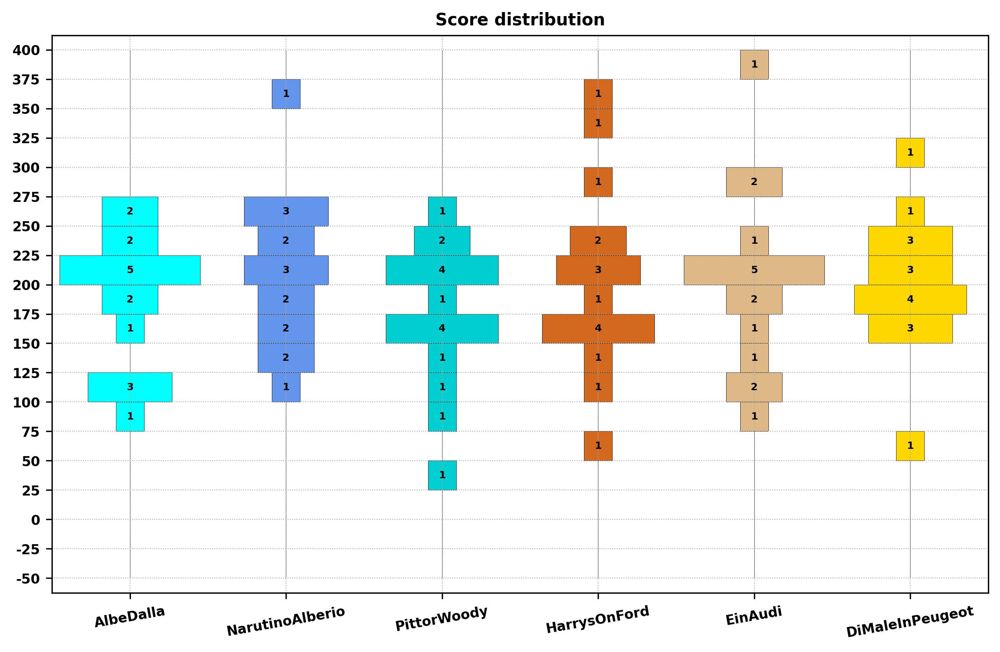

In [15]:
binScore = [ii for ii in np.arange(-50,425,25)]
fig,ax = plt.subplots(1,1, figsize=(10,6), dpi=300)

score = [[Penalties[jj][list(PT.columns).index(we)] + sum([2*PT.loc[selection[:3],we] if selection[-1]=="*" else PT.loc[selection[:3],we] for selection in myDF[jj].iloc[PT.columns.tolist().index(we)] ]) for we in PT.columns] for jj in range(len(myDF))]
binCount = [[sum([1 if ss>binScore[ii-1] and ss<=binScore[ii] else 0 for ss in score[jj]]) for ii in range(1,len(binScore))] for jj in range(len(myDF))]

for jj in range(len(myDF)):
    for ii in range(1,len(binScore)):
        ax.fill([jj+0.45*(xx*binCount[jj][ii-1])/max([max(aa) for aa in binCount]) for xx in [-1,-1,1,1]], [ii+yy for yy in [-0.5,0.5,0.5,-0.5]], color=colDF[jj], linewidth=0.2, edgecolor="k")
        ax.text(jj, ii, "" if binCount[jj][ii-1]==0 else binCount[jj][ii-1], color="k", weight="bold", fontsize=6, ha="center", va="center")
        
ax.grid(color="darkgray", linestyle=':', linewidth=0.5)
ax.set_title("Score distribution", fontsize=10, weight="bold")
ax.set_xticks(np.arange(0,len(legDF)),legDF, rotation=10, weight="bold", fontsize=8)
ax.set_yticks([yy+0.5 for yy in np.arange(0,ii+1)],binScore, rotation=0, weight="bold", fontsize=8)
ax.set_xlim(-0.5,jj+0.5)
ax.set_ylim(0,len(binScore))